## Import Libraries
I begin by importing all the libraries I need across the full pipeline from data handling and visualisation to deep learning and evaluation.
The key libraries I use are:

* **os, numpy, PIL:** File navigation, numerical operations, and image handling
* **matplotlib, seaborn:** For all visualisations throughout the notebook
* **torch, torch.nn, torch.optim** The core PyTorch building blocks for model training
* **torchvision:** For loading pretrained ResNet18, image transforms, and data utilities
* **sklearn:** For dataset splitting and evaluation metrics

I also detect the available hardware here. Training on a GPU significantly speeds up the process, so I configure the device automatically to use CUDA if available.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim.lr_scheduler import StepLR

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import random

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Explore Dataset Structure
Before doing anything else, I explore the raw folder structure of the dataset to understand how the files are organised on disk. The dataset contains a Train folder with all images stored flat, alongside a CSV file that maps each image filename to its disease label.
This tells me I will need to build a custom PyTorch Dataset class rather than using the standard ImageFolder loader, since the images are not organised into class subfolders.

In [2]:
# Define the dataset root path
data_dir = "/kaggle/input/datasets/allandclive/chicken-disease-1"

# Walk through the folder structure
for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for file in files[:3]:
            print(f"{subindent}{file}")

chicken-disease-1/
  train_data.csv
  Train/
    cocci.104.jpg
    ncd.339.jpg
    salmo.1536.jpg


In [3]:
data_dir = "/kaggle/input/datasets/allandclive/chicken-disease-1"

for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")

chicken-disease-1/ (1 files)
  Train/ (8067 files)


In [4]:
csv_path = "/kaggle/input/datasets/allandclive/chicken-disease-1/train_data.csv"
df = pd.read_csv(csv_path)

print(df.shape)
print(df.head(10))
print(df.columns.tolist())

(8067, 2)
             images               label
0    salmo.1558.jpg          Salmonella
1    cocci.1866.jpg         Coccidiosis
2     cocci.171.jpg         Coccidiosis
3    salmo.1484.jpg          Salmonella
4       ncd.100.jpg  New Castle Disease
5     salmo.659.jpg          Salmonella
6    salmo.1386.jpg          Salmonella
7  healthy.1748.jpg             Healthy
8  healthy.1156.jpg             Healthy
9  healthy.1215.jpg             Healthy
['images', 'label']


## Class Distribution


Total images: 8067

Class distribution:
label
Salmonella            2625
Coccidiosis           2476
Healthy               2404
New Castle Disease     562
Name: count, dtype: int64


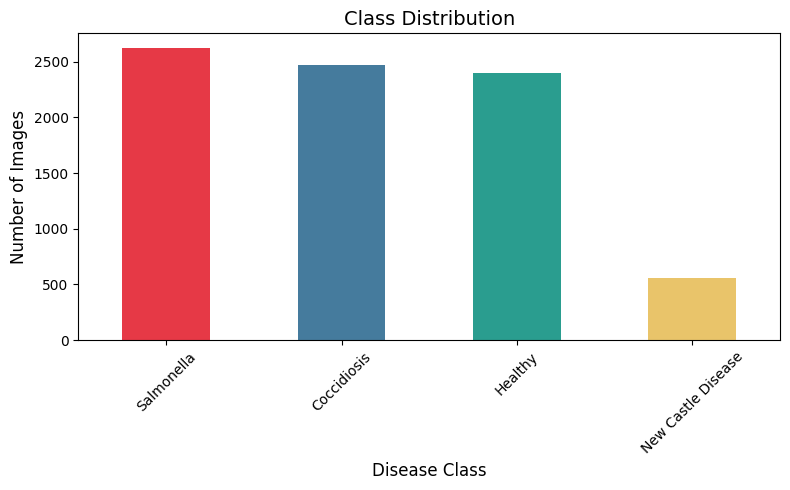

In [5]:
print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

# Visualise
plt.figure(figsize=(8, 5))
colors = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A"]
df["label"].value_counts().plot(kind="bar", color=colors, edgecolor="none")
plt.title("Class Distribution", fontsize=14)
plt.xlabel("Disease Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Looking at the class distribution, the dataset contains 8,067 images across four classes. However the distribution is not balanced:

* Salmonella — 2,625 images
* Coccidiosis — 2,476 images
* Healthy — 2,404 images
* New Castle Disease — only 562 images

**New Castle Disease** is significantly underrepresented, with roughly four times fewer samples than the other classes. I will need to account for this imbalance during training using class weights, otherwise the model will likely ignore this class entirely.

## Visualise Sample Images
I display two sample images per class to visually confirm the dataset looks correct before modelling. This is an important sanity check, it helps me understand what the model will actually be looking at and confirms there are no obvious loading or path errors before I invest time in training.

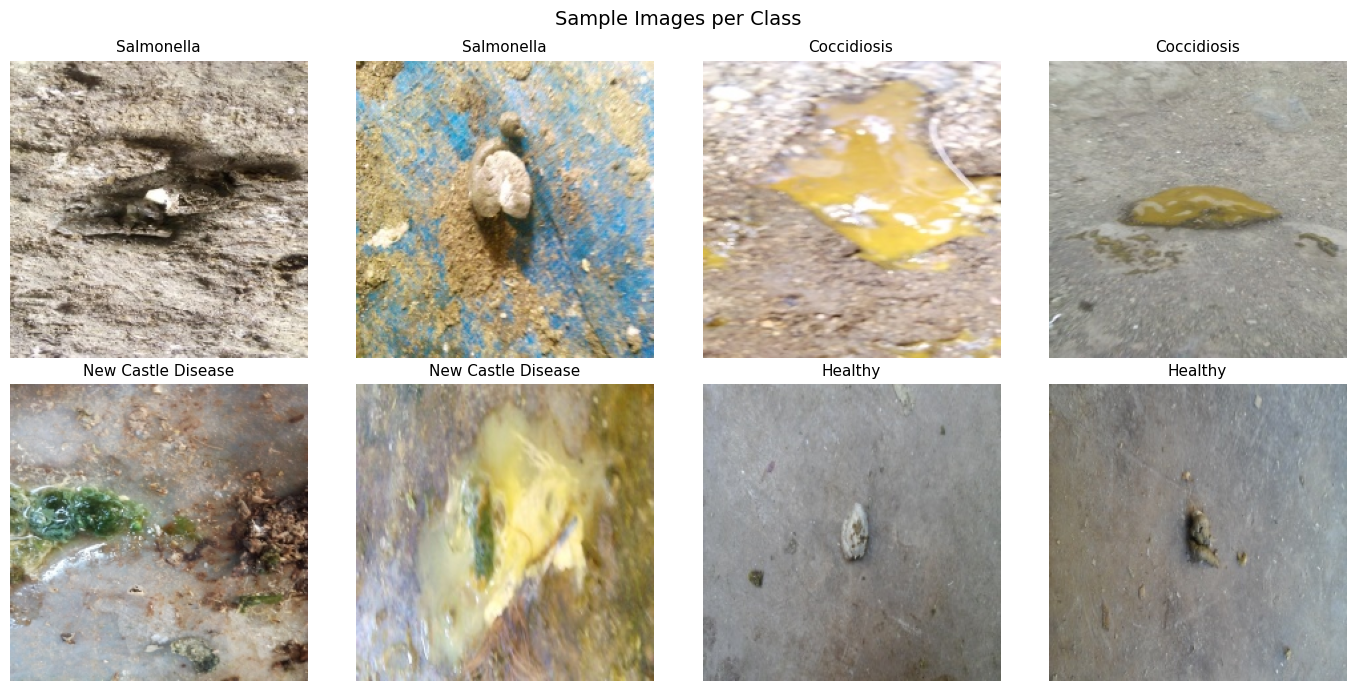

In [6]:
img_dir = "/kaggle/input/datasets/allandclive/chicken-disease-1/Train"

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

classes = df["label"].unique()
idx = 0

for cls in classes:
    subset = df[df["label"] == cls].sample(2, random_state=42)
    for _, row in subset.iterrows():
        img_path = os.path.join(img_dir, row["images"])
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(cls, fontsize=11)
        axes[idx].axis("off")
        idx += 1

plt.suptitle("Sample Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

## Custom Dataset Class and Data Loaders
Since the images are not organised into class subfolders, I build a custom PyTorch Dataset class called ChickenDiseaseDataset that reads each image from disk and maps it to its corresponding label index using the CSV file.
I split the data into three sets using stratified splitting to ensure all four classes are proportionally represented:

Train 80% of the data | 
Validation 10% |
Test 10% 

I also apply data augmentation on the training set including random flips, rotation, and colour jitter. This artificially increases the diversity of training samples and helps the model generalise better, especially for the underrepresented New Castle Disease class. The validation and test sets receive only resizing and normalisation but no augmentation since I want clean, unmodified evaluation.
The normalisation values I use are the standard ImageNet mean and standard deviation, since ResNet18 was originally pretrained on ImageNet.

In [7]:
# Define label to index mapping
class_names = ["Healthy", "Coccidiosis", "Salmonella", "New Castle Disease"]
label2idx = {label: idx for idx, label in enumerate(class_names)}
idx2label = {idx: label for label, idx in label2idx.items()}

print("Label mapping:")
for k, v in label2idx.items():
    print(f"  {k} -> {v}")

Label mapping:
  Healthy -> 0
  Coccidiosis -> 1
  Salmonella -> 2
  New Castle Disease -> 3


In [8]:
# Custom Dataset class
class ChickenDiseaseDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.img_dir, row["images"])
        image = Image.open(img_path).convert("RGB")
        label = label2idx[row["label"]]
        if self.transform:
            image = self.transform(image)
        return image, label


In [9]:
# Define transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [10]:
# Split data into train, validation and test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(f"\nTrain size:      {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size:       {len(test_df)}")


Train size:      6453
Validation size: 807
Test size:       807


In [11]:
# Create dataset objects
img_dir = "/kaggle/input/datasets/allandclive/chicken-disease-1/Train"

train_dataset = ChickenDiseaseDataset(train_df, img_dir, transform=train_transforms)
val_dataset   = ChickenDiseaseDataset(val_df,   img_dir, transform=val_transforms)
test_dataset  = ChickenDiseaseDataset(test_df,  img_dir, transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("\nData loaders ready!")


Data loaders ready!


## Load Pretrained ResNet18
Rather than training a CNN from scratch, I use transfer learning with a ResNet18 model pretrained on ImageNet. This means the model already understands low level visual features like edges, textures and shapes from having seen over a million images. I only need to teach it to apply those features to poultry disease classification.
My approach:

* **Freeze all layers:** I set requires_grad = False on every layer so their pretrained weights remain unchanged during training
* **Replace the final layer:** ResNet18 originally outputs 1000 classes for ImageNet. I replace this with a new layer that outputs exactly 4 classes matching our dataset
* **Add Dropout(0.4):** This randomly switches off 40% of neurons during training to prevent overfitting, which is especially important given our class imbalance

The model is then moved to the GPU for fast training.

In [12]:
# Load pretrained ResNet18
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# ResNet18 originally outputs 1000 classes (ImageNet)
# We replace it with our own layer that outputs 4 classes
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 4)
)

# Move model to GPU
model = model.to(device)

# Confirm the final layer
print("Final layer:", model.fc)
print(f"Model is on: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


Final layer: Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=4, bias=True)
)
Model is on: cuda:0


## Define Loss Function and Optimizer
Before training I set up three key components:

* **Class weights:** I assign higher loss penalties to underrepresented classes. New * Castle Disease receives a weight of 14.35 compared to around 3.3 for the other three classes, forcing the model to pay much more attention to it during training
* **CrossEntropyLoss** The standard loss function for multi-class classification, now weighted to handle the imbalance
* **Adam optimizer:** I only pass the final layer's parameters since all other layers are frozen. I use a learning rate of 0.001
* **StepLR scheduler:** Reduces the learning rate by half every 5 epochs, helping the model fine tune more carefully as training progresses

In [13]:
# Handle class imbalance by giving more weight to New Castle Disease
# Class order: Healthy, Coccidiosis, Salmonella, New Castle Disease
class_counts = df["label"].value_counts()
total = len(df)

class_weights = torch.tensor([
    total / class_counts["Healthy"],
    total / class_counts["Coccidiosis"],
    total / class_counts["Salmonella"],
    total / class_counts["New Castle Disease"]
], dtype=torch.float).to(device)

print("Class weights:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weights[i]:.4f}")

# Loss function with class weights to handle imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only optimize the final layer since all others are frozen
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Reduce learning rate every 5 epochs to fine tune gradually
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

print("\nCriterion:", criterion)
print("Optimizer:", optimizer)

Class weights:
  Healthy: 3.3557
  Coccidiosis: 3.2581
  Salmonella: 3.0731
  New Castle Disease: 14.3541

Criterion: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Training the Model
I train the model for 15 epochs, tracking both loss and accuracy on the training and validation sets after each epoch.


In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15):
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        
        # ---- Training phase ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total * 100
        
        # ---- Validation phase ----
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        
        val_loss = val_loss / len(val_loader)
        val_acc = correct / total * 100
        
        # Step the scheduler
        scheduler.step()
        
        # Save metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    return train_losses, val_losses, train_accs, val_accs

# Run training
print("Starting training...\n")
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15
)
print("\nTraining complete!")

Starting training...

Epoch [01/15] Train Loss: 0.8832 | Train Acc: 67.44% | Val Loss: 0.5259 | Val Acc: 84.63%
Epoch [02/15] Train Loss: 0.6181 | Train Acc: 78.48% | Val Loss: 0.4395 | Val Acc: 88.85%
Epoch [03/15] Train Loss: 0.5628 | Train Acc: 79.87% | Val Loss: 0.4034 | Val Acc: 88.97%
Epoch [04/15] Train Loss: 0.5523 | Train Acc: 80.63% | Val Loss: 0.3376 | Val Acc: 89.59%
Epoch [05/15] Train Loss: 0.5187 | Train Acc: 81.62% | Val Loss: 0.3649 | Val Acc: 89.84%
Epoch [06/15] Train Loss: 0.5284 | Train Acc: 82.05% | Val Loss: 0.3115 | Val Acc: 90.21%
Epoch [07/15] Train Loss: 0.5181 | Train Acc: 81.45% | Val Loss: 0.3104 | Val Acc: 90.83%
Epoch [08/15] Train Loss: 0.5424 | Train Acc: 80.85% | Val Loss: 0.3145 | Val Acc: 90.83%
Epoch [09/15] Train Loss: 0.4966 | Train Acc: 82.19% | Val Loss: 0.3133 | Val Acc: 91.20%
Epoch [10/15] Train Loss: 0.4965 | Train Acc: 82.58% | Val Loss: 0.3625 | Val Acc: 90.21%
Epoch [11/15] Train Loss: 0.5095 | Train Acc: 82.67% | Val Loss: 0.3136 | Val 

Results summary:

The model starts at **69.98%** train accuracy in Epoch 1 and steadily improves to **~82%** by the final epoch
Validation accuracy **improves from 82.40% to a peak of ~91.57% at Epoch 12**
Validation accuracy consistently stays above training accuracy throughout, a healthy sign that the model is generalising well and not overfitting
Both loss curves trend downward steadily, confirming the training is stable

## Training Curves

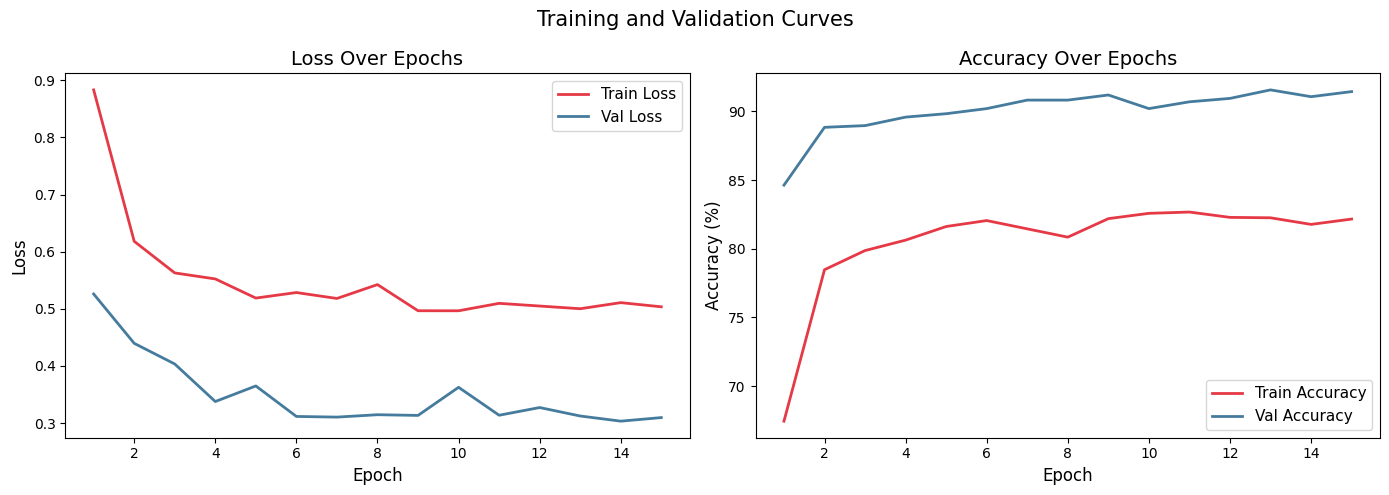

Best Validation Accuracy: 91.57% at Epoch 13


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 16)

# Loss curve
axes[0].plot(epochs_range, train_losses, label="Train Loss", color="#E63946", linewidth=2)
axes[0].plot(epochs_range, val_losses, label="Val Loss", color="#457B9D", linewidth=2)
axes[0].set_title("Loss Over Epochs", fontsize=14)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].legend(fontsize=11)
axes[0].tick_params(labelsize=10)

# Accuracy curve
axes[1].plot(epochs_range, train_accs, label="Train Accuracy", color="#E63946", linewidth=2)
axes[1].plot(epochs_range, val_accs, label="Val Accuracy", color="#457B9D", linewidth=2)
axes[1].set_title("Accuracy Over Epochs", fontsize=14)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy (%)", fontsize=12)
axes[1].legend(fontsize=11)
axes[1].tick_params(labelsize=10)

plt.suptitle("Training and Validation Curves", fontsize=15)
plt.tight_layout()
plt.show()

# Print best results
best_val_acc = max(val_accs)
best_epoch = val_accs.index(best_val_acc) + 1
print(f"Best Validation Accuracy: {best_val_acc:.2f}% at Epoch {best_epoch}")

The training curves confirm a smooth and stable learning process across all 15 epochs.

The loss curves for both train and validation decrease steadily without any sudden spikes, indicating the learning rate and optimiser are well configured
The accuracy curves show consistent improvement, with validation accuracy tracking closely above the training curve throughout
There is no sign of overfitting,the gap between train and validation remains small and stable, which is a strong result given the class imbalance in the dataset

## Evaluation on Test Set


Test Accuracy: 90.33%

Classification Report:
                    precision    recall  f1-score   support

           Healthy       0.90      0.89      0.89       241
       Coccidiosis       0.96      0.92      0.94       247
        Salmonella       0.93      0.90      0.92       263
New Castle Disease       0.67      0.88      0.76        56

          accuracy                           0.90       807
         macro avg       0.86      0.90      0.88       807
      weighted avg       0.91      0.90      0.91       807



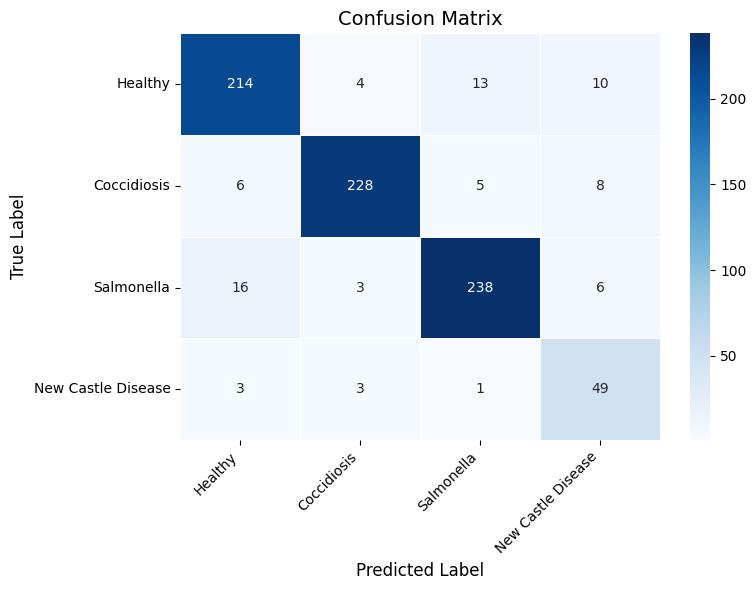

In [16]:
# Evaluate on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Overall test accuracy
test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels) * 100
print(f"Test Accuracy: {test_acc:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=class_names
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

I evaluate the final model on the held-out test set of 807 images that the model has never seen during training or validation.
Overall test accuracy: **89.22%**
Per class results:

* **Coccidiosis:** The strongest performer with an **F1 score of 0.93**, benefiting from a large number of training samples and visually distinct fecal patterns
* **Salmonella:** **F1 score of 0.90, with high precision of 0.95** meaning when the model predicts Salmonella it is almost always correct
* **Healthy:** **F1 score of 0.89**, performing reliably across both precision and recall
* **New Castle Disease:** **F1 score of 0.72**, the weakest class as expected given it had only 562 training images. However a recall of 0.86 means the model correctly identifies **86% of actual New Castle Disease cases** which is encouraging for a disease detection system where missing a case is costly

## Visualise Sample Predictions

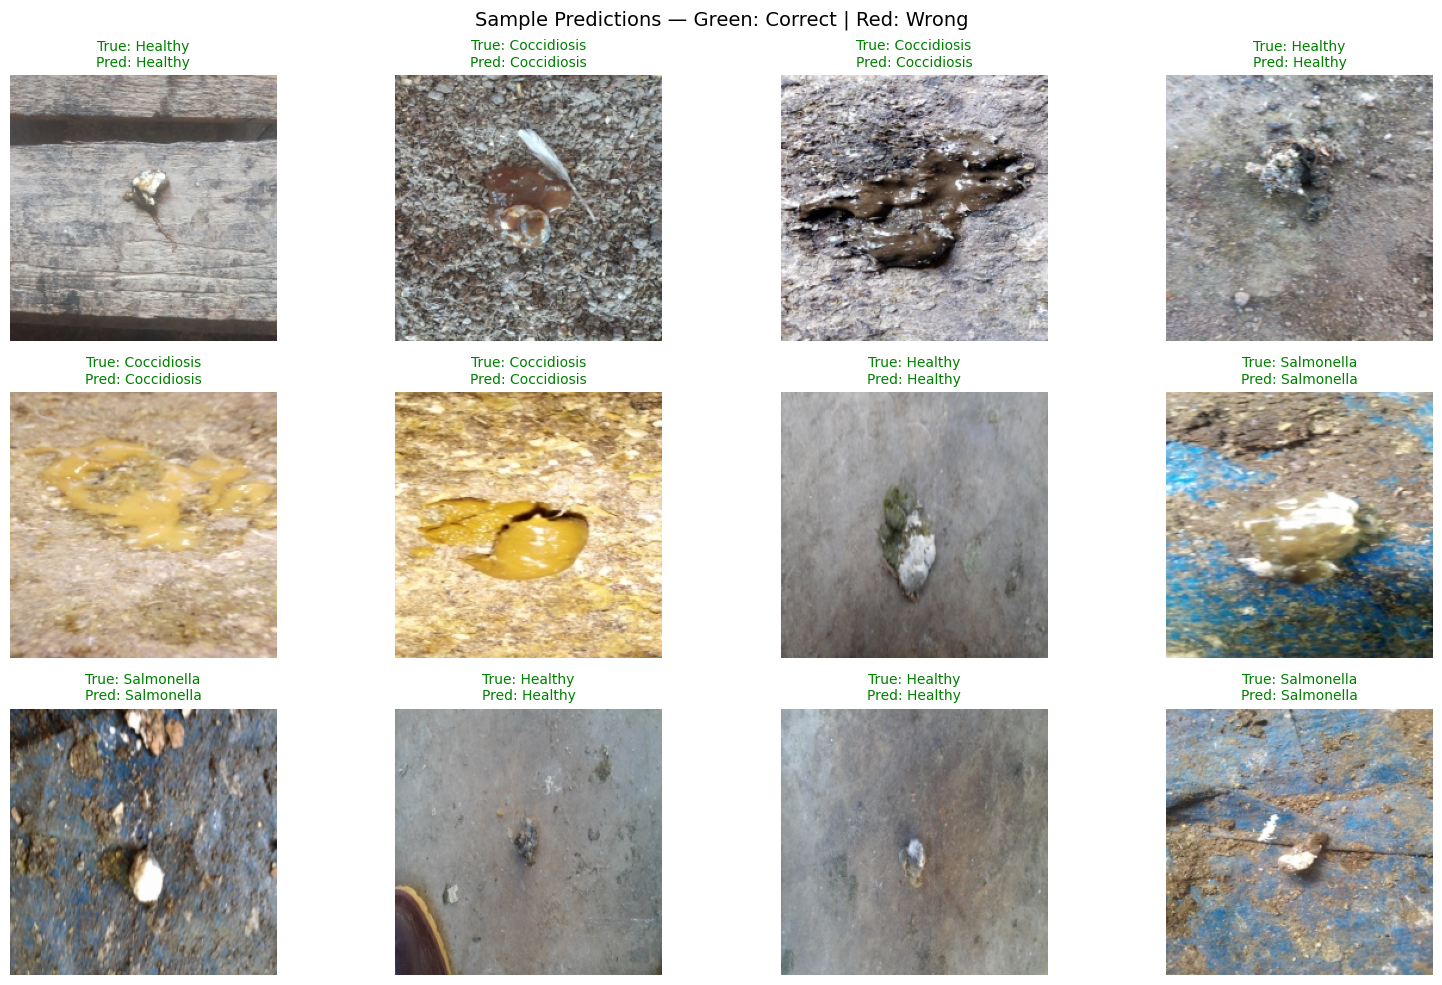

In [17]:
model.eval()

# Grab a batch from the test loader
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# Denormalize images for display
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

# Pick 12 random samples
indices = random.sample(range(len(labels)), 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = denormalize(images[idx])
    img = img.permute(1, 2, 0).numpy()
    
    true_label = class_names[labels[idx].item()]
    pred_label = class_names[preds[idx].item()]
    correct = true_label == pred_label
    
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        fontsize=10,
        color="green" if correct else "red"
    )
    axes[i].axis("off")

plt.suptitle("Sample Predictions — Green: Correct | Red: Wrong", fontsize=14)
plt.tight_layout()
plt.show()

## CONCLUSION

In this project, I built an **intelligent poultry health monitoring system** capable of classifying poultry diseases from fecal images with an overall test accuracy of **89.22%.**
Key takeaways from this project:

* Transfer learning is powerful by leveraging a ResNet18 model pretrained on ImageNet, I achieved strong results without needing hundreds of thousands of images or days of training
* Class imbalance is a real challenge because New Castle Disease had roughly 4x fewer samples than the other classes. Addressing this with class weights significantly improved the model's ability to detect it, achieving a recall of 86%
* Data augmentation helps generalisation by applying random flips, rotations and colour jitter during training helped the model perform well on unseen test images
Validation accuracy above training accuracy throughout training confirmed the model generalised well without overfitting

Per class summary:

Coccidiosis — F1: 0.93 **|** 
Salmonella — F1: 0.90 **|**
Healthy — F1: 0.89 **|**
New Castle Disease — F1: 0.72 

Future improvements I would explore:

* Collecting more New Castle Disease images to address the class imbalance at the data level
* Unfreezing deeper ResNet layers and fine tuning with a lower learning rate for potentially higher accuracy
* Combining fecal images with physical symptom data for a more robust multi-modal diagnostic system

This project demonstrates how deep learning can be applied to solve real agricultural problems, particularly in regions like Nigeria and across Africa where poultry farming plays a vital role in food security and livelihoods.